In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams['figure.dpi'] = 300
# set tight layout for all plots
plt.rcParams['figure.autolayout'] = True

SAVE_FIGS=True

In [3]:
Cs137_path='data/pmt_spectroscopy/vp2ps_20250320-154238_cs137_1h_15cm.csv'
Co60_path='data/pmt_spectroscopy/vp2ps_20250320-181313_co60_12h_20cm.csv'
Na22_path='data/pmt_spectroscopy/vp2ps_20250320-171041_na22_1h_30cm.csv'
Cs137_df = pd.read_csv(Cs137_path)
Co60_df = pd.read_csv(Co60_path)
Na22_df = pd.read_csv(Na22_path)

# load only the first half of the co60 data
# Co60_df = Co60_df.iloc[:len(Co60_df)//2]

Cs137_df['mV'] = Cs137_df['V'] * 1000
Co60_df['mV'] = Co60_df['V'] * 1000
Na22_df['mV'] = Na22_df['V'] * 1000

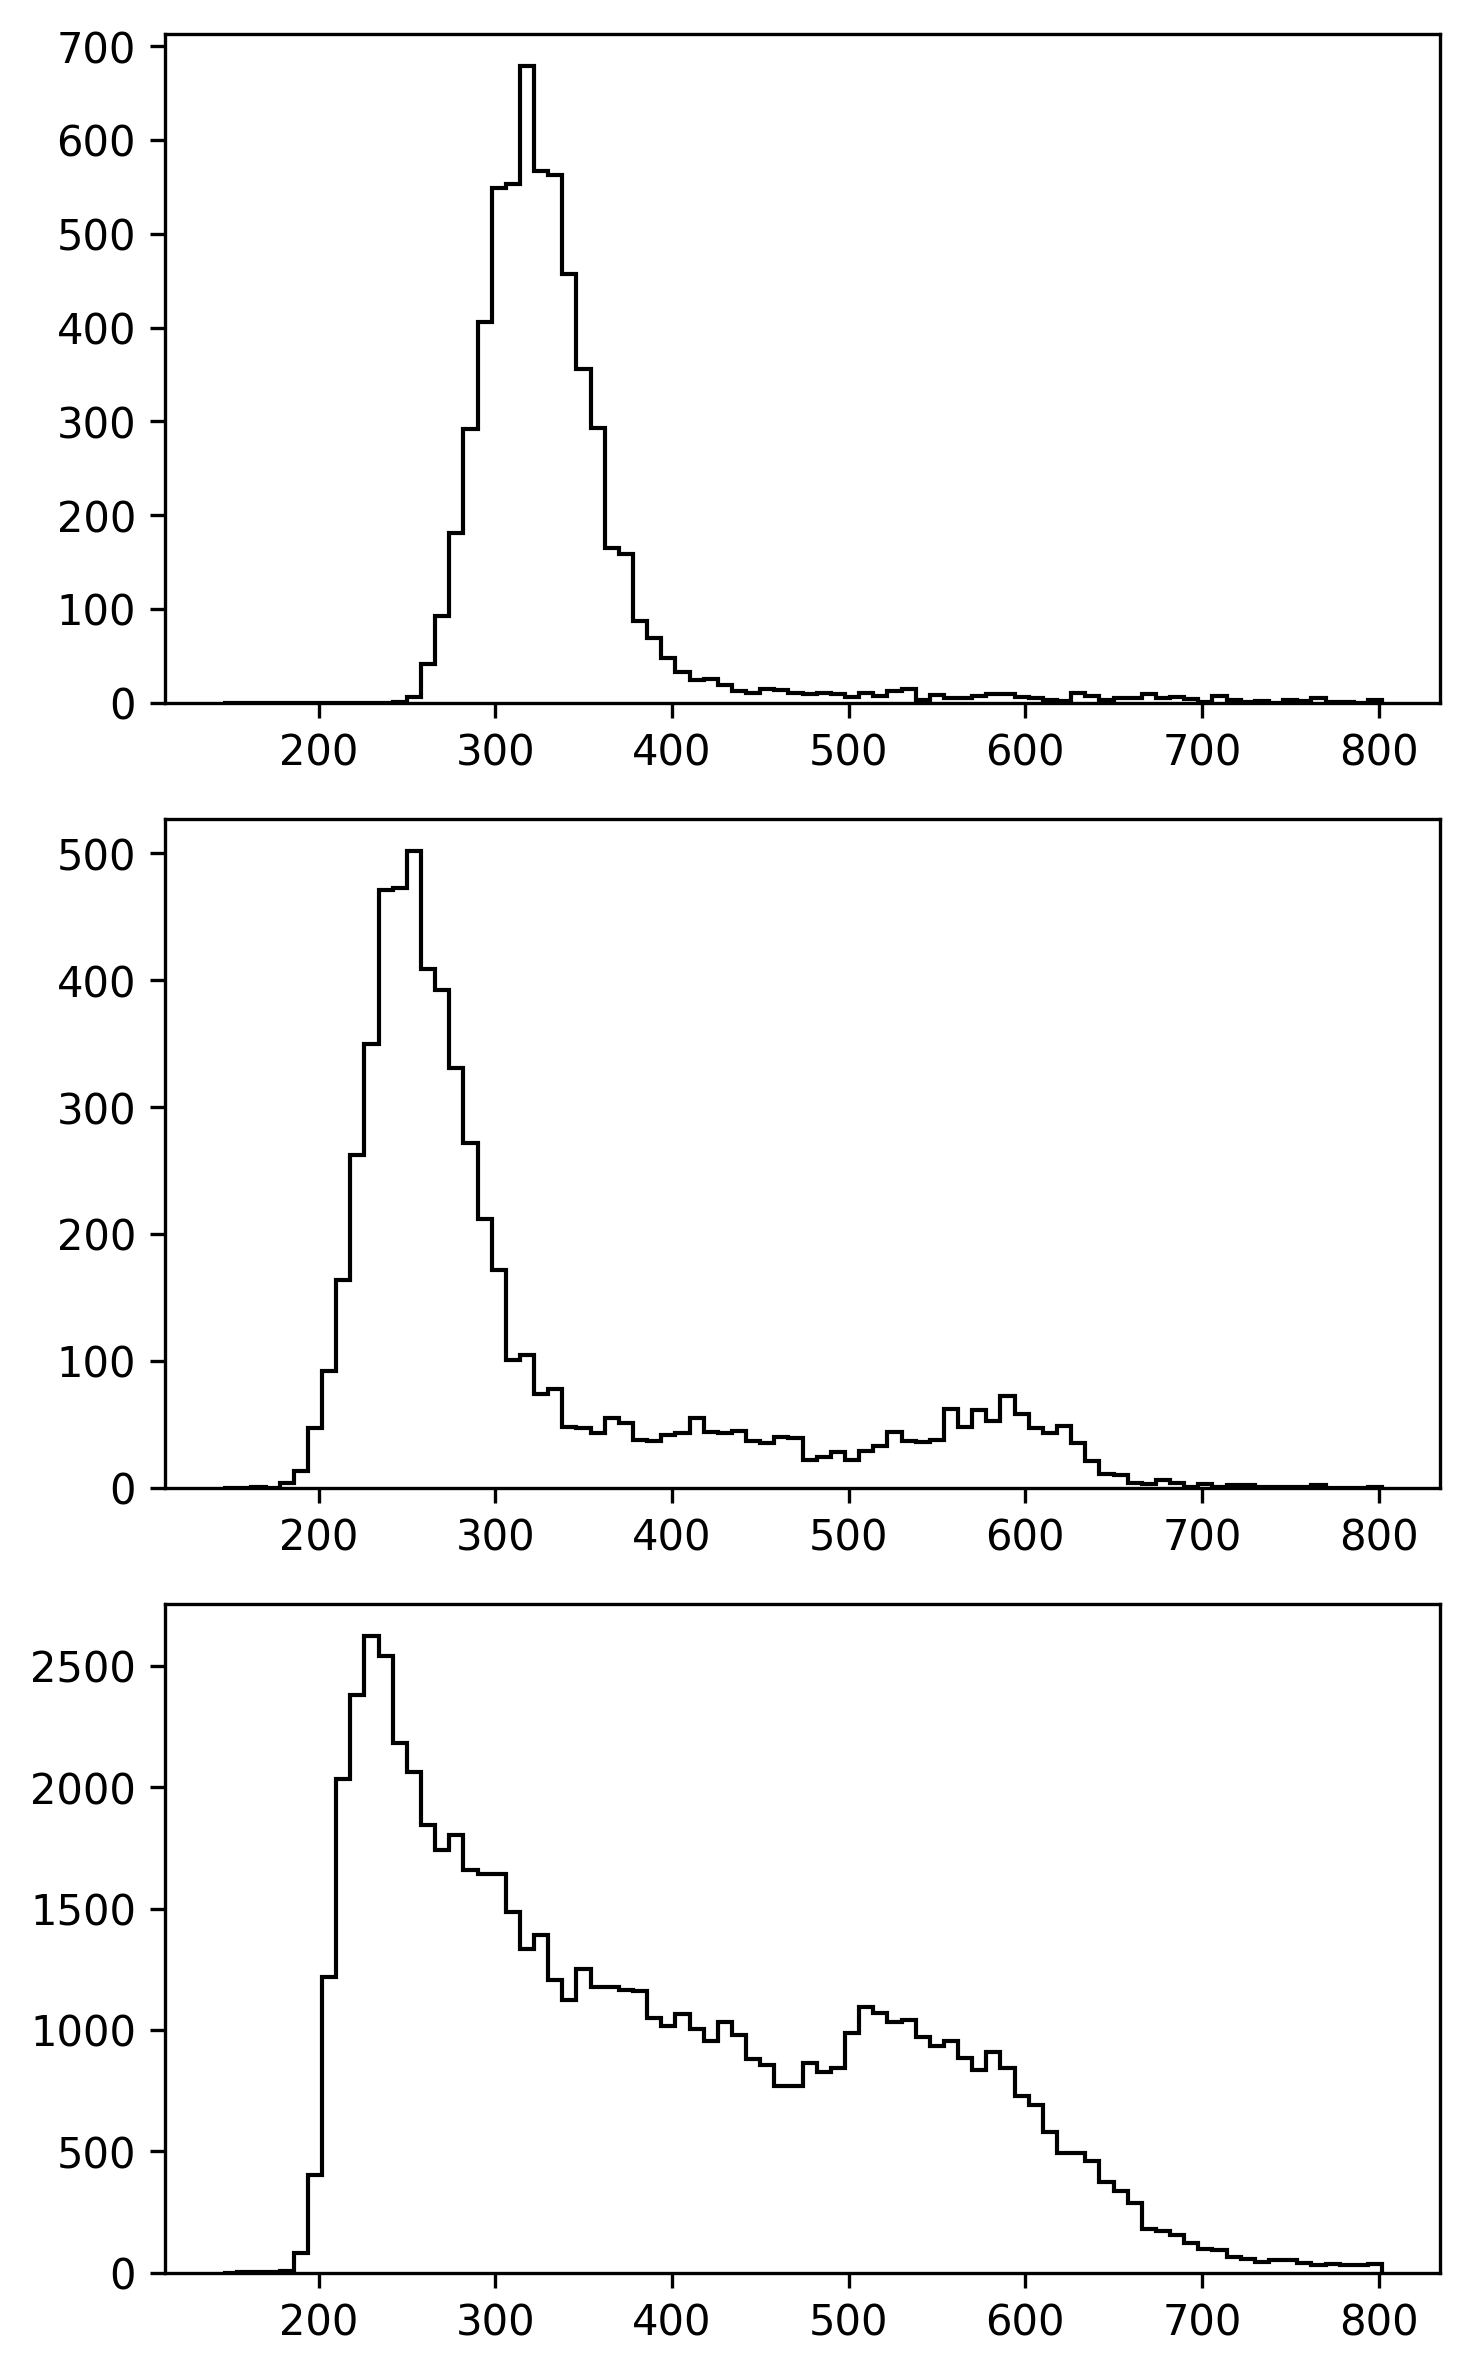

In [4]:
min =150 
max = 800
step = 8 #mV
hist_bins = np.arange(min-step/2, max+step/2, step)
fig, ax = plt.subplots(3,1,figsize=(5, 8))
ax[0].hist(Cs137_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Cs137', histtype='step')
ax[1].hist(Na22_df['mV'], range=(min,max),bins=hist_bins, color='black', label='Na22', histtype='step')
ax[2].hist(Co60_df['mV'], range=(min,max),bins=hist_bins, color='black', label='Co60', histtype='step')
plt.show()


/tmp/ipykernel_1388212/2216774354.py:6: RuntimeWarning: divide by zero encountered in divide
  return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + B*x**2 + C*x + D


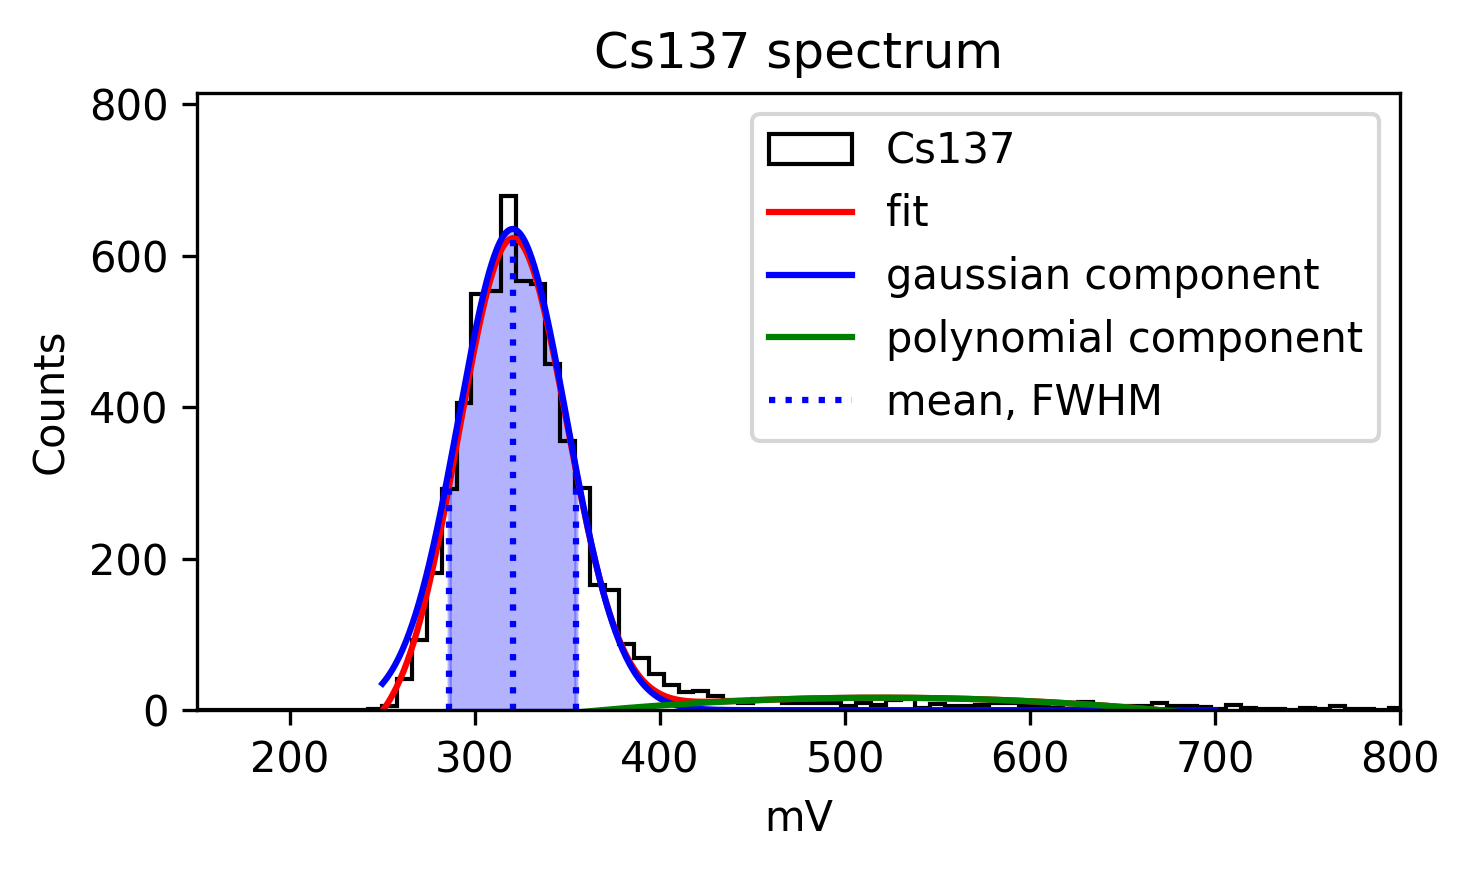

In [5]:

fig, ax = plt.subplots(1,1,figsize=(5,3))
count, bins, _ = ax.hist(Cs137_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Cs137', histtype='step')
bin_centers = 0.5*(bins[1:] + bins[:-1])

def fit_func(x, A, mu, sigma, B, C, D):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + B*x**2 + C*x + D

fit_range = (250, 700)
counts_fit = count[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
bin_centers_fit = bin_centers[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
initial_guess = [1e5, 350, 2, 1, 1,1] 
popt, pcov = curve_fit(fit_func, bin_centers_fit, counts_fit, p0=initial_guess)
x_fit = np.linspace(fit_range[0], fit_range[1], 1000)
y_fit = fit_func(x_fit, *popt)
ax.plot(x_fit, y_fit, color='red', label='fit')
y_gaussian = fit_func(x_fit, popt[0], popt[1], popt[2], 0, 0, 0)
ax.plot(x_fit, y_gaussian, color='blue', label='gaussian component')
y_polynomial = fit_func(x_fit, 0, 0, 0, popt[3], popt[4], popt[5])
ax.plot(x_fit, y_polynomial, color='green', label='polynomial component')



fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
peak_middle = popt[1]
ax.vlines(peak_middle, 0, popt[0], color='blue', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle - fwhm/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle + fwhm/2, 0, popt[0]/2, color='blue', linestyle='dotted')

ax.fill_between(x_fit, y_gaussian, 0, where=(x_fit >= peak_middle - fwhm/2) & (x_fit <= peak_middle + fwhm/2), color='blue', alpha=0.3)
Cs137_peak1_mean=popt[1]
Cs137_peak1_fwhm=fwhm

ax.legend()
ax.set_title('Cs137 spectrum')
ax.set_ylim(0, 1.2*np.max(counts_fit))
ax.set_xlim(min, max)
ax.set_xlabel('mV')
ax.set_ylabel('Counts')
if SAVE_FIGS:
    plt.savefig('plots/pmt_spectroscopy/long_exposure/Cs137_spectrum.png', dpi=300)
plt.show()

/tmp/ipykernel_1388212/3155950176.py:10: RuntimeWarning: divide by zero encountered in divide
  return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B*x**2 + C*x + D


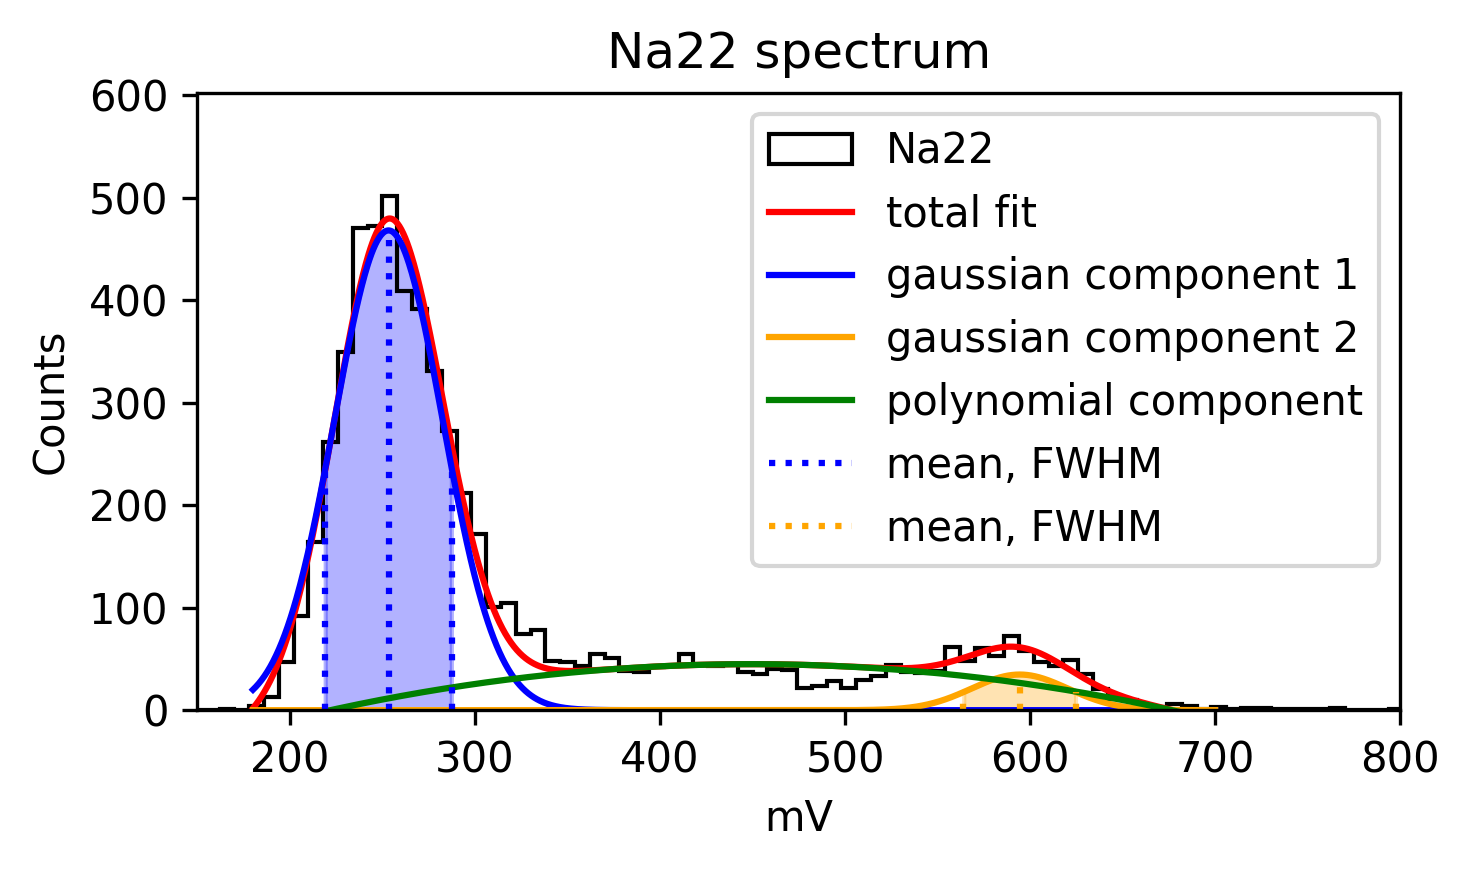

In [6]:
fig, ax = plt.subplots(1,1,figsize=(5,3))
count, bins, _ = ax.hist(Na22_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Na22', histtype='step')
bin_centers = 0.5*(bins[1:] + bins[:-1])

fit_range = (180, 700)
counts_fit = count[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
bin_centers_fit = bin_centers[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
# define a fit function - two gauss curves plus an exponential curve
def fit_func(x, A1, mu1, sigma1, A2, mu2, sigma2, B, C, D):
    return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B*x**2 + C*x + D
initial_guess = [1e3, 260, 2, 1e2, 600, 2,-0.001, 1,1]
popt, pcov = curve_fit(fit_func, bin_centers_fit, counts_fit, p0=initial_guess, maxfev=100000)

x_fit = np.linspace(fit_range[0], fit_range[1], 1000)
y_fit = fit_func(x_fit, *popt)
y_gaussian1 = fit_func(x_fit, popt[0], popt[1], popt[2], 0, 0, 0, 0,0,0)
y_gaussian2 = fit_func(x_fit, 0, 0, 0, popt[3], popt[4], popt[5], 0, 0,0)
y_polynomial = fit_func(x_fit, 0, 0, 0, 0, 0, 0, popt[6], popt[7],popt[8])

ax.plot(x_fit, y_fit, color='red', label='total fit')
ax.plot(x_fit, y_gaussian1, color='blue', label='gaussian component 1')
ax.plot(x_fit, y_gaussian2, color='orange', label='gaussian component 2')
ax.plot(x_fit, y_polynomial, color='green', label='polynomial component')


fwhm1 = 2 * np.sqrt(2 * np.log(2)) * popt[2]
fwhm2 = 2 * np.sqrt(2 * np.log(2)) * popt[5]
peak_middle1 = popt[1]
peak_middle2 = popt[4]
ax.vlines(peak_middle1, 0, popt[0], color='blue', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle1 - fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle1 + fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle2, 0, popt[3], color='orange', linestyle='dotted', label='mean, FWHM')

ax.vlines(peak_middle2 - fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.vlines(peak_middle2 + fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.fill_between(x_fit, y_gaussian1, 0, where=(x_fit >= peak_middle1 - fwhm1/2) & (x_fit <= peak_middle1 + fwhm1/2), color='blue', alpha=0.3)
ax.fill_between(x_fit, y_gaussian2, 0, where=(x_fit >= peak_middle2 - fwhm2/2) & (x_fit <= peak_middle2 + fwhm2/2), color='orange', alpha=0.3)

Na22_peak1_mean=popt[1]
Na22_peak1_fwhm=fwhm1
Na22_peak2_mean=popt[4]
Na22_peak2_fwhm=fwhm2

ax.legend()
ax.set_title('Na22 spectrum')
ax.set_ylim(0, 1.2*np.max(counts_fit))
ax.set_xlim(min, max)
ax.set_xlabel('mV')
ax.set_ylabel('Counts')
if SAVE_FIGS:
    plt.savefig('plots/pmt_spectroscopy/long_exposure/Na22_spectrum.png', dpi=300)
plt.show()

/tmp/ipykernel_1388212/1217980539.py:11: RuntimeWarning: divide by zero encountered in divide
  gauss2 = A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2)
/tmp/ipykernel_1388212/1217980539.py:10: RuntimeWarning: divide by zero encountered in divide
  gauss1 = A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2)


fit parameters:
param 0: 314.89
param 1: 516.18
param 2: 17.93
param 3: 394.91
param 4: 572.74
param 5: 36.46
param 6: 0.00
param 7: -4.25
param 8: 2445.24


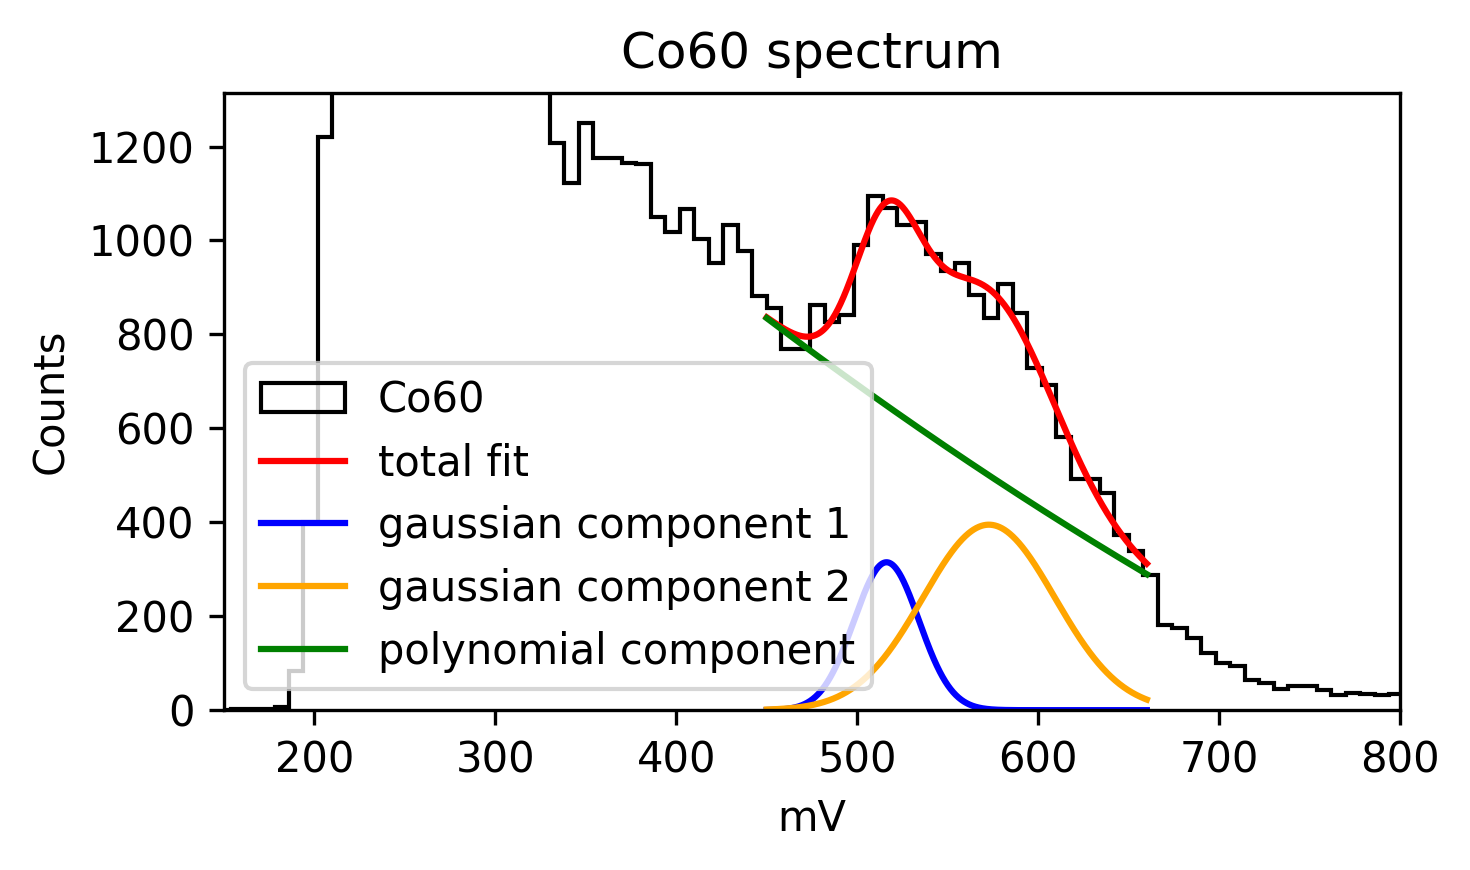

In [40]:

fig, ax = plt.subplots(1,1,figsize=(5,3))
count, bins, _ = ax.hist(Co60_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Co60', histtype='step')
bin_centers = 0.5*(bins[1:] + bins[:-1])

fit_range = (450, 660)
counts_fit = count[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
bin_centers_fit = bin_centers[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
# define a fit function - two gauss curves plus an exponential curve
def fit_func(x, A1, mu1, sigma1, A2, mu2, sigma2, B, C, D):
    gauss1 = A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2)
    gauss2 = A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2)
    polynomial =B *x**2 + C*x + D
    return gauss1 + gauss2 + polynomial 

initial_guess = [2896,540, 43, 300, 620, 20, 1, 142, 199999]


popt, pcov = curve_fit(fit_func, bin_centers_fit, counts_fit, p0=initial_guess, maxfev=100000)
x_fit = np.linspace(fit_range[0], fit_range[1], 1000)
y_fit = fit_func(x_fit, *popt)
y_gaussian1 = fit_func(x_fit, popt[0], popt[1], popt[2], 0, 0, 0, 0,0,0)
y_gaussian2 = fit_func(x_fit, 0, 0, 0, popt[3], popt[4], popt[5], 0, 0,0)
y_poly = fit_func(x_fit, 0, 0, 0, 0, 0, 0, popt[6], popt[7],popt[8])
ax.plot(x_fit, y_fit, color='red', label='total fit')
ax.plot(x_fit, y_gaussian1, color='blue', label='gaussian component 1')
ax.plot(x_fit, y_gaussian2, color='orange', label='gaussian component 2')
ax.plot(x_fit, y_poly, color='green', label='polynomial component')

fwhm1 = 2 * np.sqrt(2 * np.log(2)) * popt[2]
fwhm2 = 2 * np.sqrt(2 * np.log(2)) * popt[5]
# peak_middle1 = popt[1]
# peak_middle2 = popt[4]
# ax.vlines(peak_middle1, 0, popt[0], color='blue', linestyle='dotted', label='mean, FWHM')
# ax.vlines(peak_middle1 - fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
# ax.vlines(peak_middle1 + fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
# ax.vlines(peak_middle2, 0, popt[3], color='orange', linestyle='dotted', label='mean, FWHM')
# ax.vlines(peak_middle2 - fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
# ax.vlines(peak_middle2 + fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
# ax.fill_between(x_fit, y_gaussian1, 0, where=(x_fit >= peak_middle1 - fwhm1/2) & (x_fit <= peak_middle1 + fwhm1/2), color='blue', alpha=0.3)
# ax.fill_between(x_fit, y_gaussian2, 0, where=(x_fit >= peak_middle2 - fwhm2/2) & (x_fit <= peak_middle2 + fwhm2/2), color='orange', alpha=0.3)

Co60_peak1_mean=popt[1]
Co60_peak1_fwhm=fwhm1
Co60_peak2_mean=popt[4]
Co60_peak2_fwhm=fwhm2


# present the fit parameters
print('fit parameters:')
for i, param in enumerate(popt):
    print(f'param {i}: {param:.2f}')

ax.legend()
ax.set_title('Co60 spectrum')
ax.set_ylim(0, 1.2*np.max(counts_fit))
ax.set_xlim(min, max)
ax.set_xlabel('mV')
ax.set_ylabel('Counts')

if SAVE_FIGS:
    plt.savefig('plots/pmt_spectroscopy/long_exposure/C060_spectrum.png', dpi=300)
plt.show()